# 2026-27 season projection

Same score-prediction methodology as `outputs.ipynb`:

    home_xg = exp(baseline + home_adv + att_str[home] + def_str[away]) + BASELINE_HOME_PENS
    away_xg = exp(baseline + att_str[away] + def_str[home]) + BASELINE_AWAY_PENS

(non-penalty model + a fixed penalty-goals add-back, `_update_table` for
pts/GD/GF-tiebreak standings — same as `outputs.ipynb`/`src/simulation.py`.)

**The one real difference:** `outputs.ipynb` draws `att_str`/`def_str`/`baseline`/
`home_adv` from a posterior *fitted on this season's actual matches*. There
are no 2026-27 matches yet, so there's no such posterior. Instead:

- `att_str`/`def_str` are drawn from `manual_priors_2026_27.py`'s `(mu, sigma)`
  — i.e. prior-predictive draws, since the prior *is* the whole belief state
  before any data arrives.
- `baseline`/`home_adv` are resampled from **last season's actual posterior**
  (`model_traces/v1/trace_Premier_League_2025-2026.nc`) — these are
  season-independent nuisance parameters (average scoring rate, home
  advantage), not team-specific, so there's no reason to reset them to a vague
  prior when last season's fitted values are sitting right there.

In [1]:
import sys, os
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
from pathlib import Path

_here = Path.cwd()
if not (_here / 'outputs.ipynb').exists():
    for _c in [_here / 'premier_league',
               _here / 'non_penalty_bayes' / 'premier_league',
               _here / 'team_strength' / 'non_penalty_bayes' / 'premier_league']:
        if _c.exists():
            os.chdir(_c)
            break

NOTEBOOK_DIR = Path.cwd().resolve()
NP_BAYES_DIR = str(NOTEBOOK_DIR.parent)
sys.path.insert(0, NP_BAYES_DIR)

from src.simulation import _update_table
from manual_priors_2026_27 import MANUAL_ATT_PRIORS, MANUAL_DEF_PRIORS

TRACE_2025_26 = NOTEBOOK_DIR / 'model_traces' / 'v1' / 'trace_Premier_League_2025-2026.nc'
OUT_DIR = NOTEBOOK_DIR / 'outputs'
OUT_DIR.mkdir(exist_ok=True)

# same fixed penalty-goals add-back as outputs.ipynb (non-penalty model -> approx total goals)
BASELINE_HOME_PENS = 0.157 * 0.78
BASELINE_AWAY_PENS = 0.101 * 0.78

N_SIMS = 10_000
RNG = np.random.default_rng(42)

teams = sorted(MANUAL_ATT_PRIORS.keys())
n_teams = len(teams)
team_mapping = {t: i for i, t in enumerate(teams)}
PROMOTED = ['Hull', 'Coventry', 'Ipswich']

mu_att    = np.array([MANUAL_ATT_PRIORS[t][0] for t in teams])
sigma_att = np.array([MANUAL_ATT_PRIORS[t][1] for t in teams])
mu_def    = np.array([MANUAL_DEF_PRIORS[t][0] for t in teams])
sigma_def = np.array([MANUAL_DEF_PRIORS[t][1] for t in teams])

trace_2025_26 = az.from_netcdf(TRACE_2025_26)
baseline_pool = trace_2025_26.posterior['baseline'].values.flatten()
home_adv_pool = trace_2025_26.posterior['home_adv'].values.flatten()
print(f"{n_teams} teams  |  baseline/home_adv pool: {len(baseline_pool)} posterior draws from 2025-26")

20 teams  |  baseline/home_adv pool: 4000 posterior draws from 2025-26


## Team strength table (vs. average opponent)

Same "Bayesian avg-vs-all-opponents" construction as `outputs.ipynb`: play out
every ordered pairing of the 20 teams once (380 fixtures = a full home-and-away
round robin), using posterior/prior *means* — `att_str`/`def_str` mean = the
prior mu (already the model's belief about the mean, no data yet to update
it), `baseline`/`home_adv` mean = last season's posterior mean. Averaging each
team's goals for/against across all 19 opponents gives goals-for/against/diff
per game against a league-average opponent.

In [2]:
baseline_mean = baseline_pool.mean()
home_adv_mean = home_adv_pool.mean()

team_stats = {t: {"goals_for": 0.0, "goals_against": 0.0, "matches": 0} for t in teams}

for home_team in teams:
    hi = team_mapping[home_team]
    for away_team in teams:
        if home_team == away_team:
            continue
        ai = team_mapping[away_team]
        home_lam = np.exp(baseline_mean + home_adv_mean + mu_att[hi] + mu_def[ai])
        away_lam = np.exp(baseline_mean + mu_att[ai] + mu_def[hi])

        hg = home_lam + BASELINE_HOME_PENS
        ag = away_lam + BASELINE_AWAY_PENS

        team_stats[home_team]["goals_for"]     += hg
        team_stats[home_team]["goals_against"] += ag
        team_stats[home_team]["matches"]       += 1
        team_stats[away_team]["goals_for"]     += ag
        team_stats[away_team]["goals_against"] += hg
        team_stats[away_team]["matches"]       += 1

ratings_df = pd.DataFrame([{
    "team":          t,
    "goals_for":     team_stats[t]["goals_for"]     / team_stats[t]["matches"],
    "goals_against": team_stats[t]["goals_against"] / team_stats[t]["matches"],
    "goal_diff":     (team_stats[t]["goals_for"] - team_stats[t]["goals_against"]) / team_stats[t]["matches"],
    "promoted":      t in PROMOTED,
} for t in teams]).sort_values("goal_diff", ascending=False).reset_index(drop=True)
ratings_df.index += 1

pd.set_option('display.float_format', '{:.3f}'.format)
ratings_df

,team,goals_for,goals_against,goal_diff,promoted
1,Arsenal,1.783,0.879,0.904,False
2,Man City,1.899,1.080,0.819,False
3,Liverpool,1.688,1.204,0.484,False
4,Chelsea,1.662,1.219,0.443,False
5,Man United,1.660,1.239,0.421,False
6,Brighton,1.465,1.240,0.225,False
7,Bournemouth,1.476,1.363,0.113,False
8,Brentford,1.418,1.313,0.106,False
9,Newcastle,1.437,1.333,0.105,False
10,Tottenham,1.364,1.319,0.045,False


## Season simulation

`N_SIMS` full-season Monte Carlo draws (same `_update_table`/points-then-GD-
then-GF tiebreak as `outputs.ipynb`'s cell 10). Every fixture in the 380-game
round robin is simulated in every draw (no actual results to seed the table
with, unlike mid-season `outputs.ipynb`). Each draw:

1. Samples a fresh `att_str_raw`/`def_str_raw` per team from the prior
   `Normal(mu, sigma)`, then re-centers to zero mean — replicating
   `src/model.py`'s own `att_str = att_str_raw - mean(att_str_raw)` step, so
   this is a true prior-predictive draw, not just a point estimate.
2. Samples one `(baseline, home_adv)` pair from last season's posterior pool.
3. Computes all 380 fixtures' expected goals, draws a Poisson score for each,
   and updates the table.

In [3]:
FIXTURES = [(h, a) for h in teams for a in teams if h != a]
hri = np.array([team_mapping[h] for h, a in FIXTURES])
ari = np.array([team_mapping[a] for h, a in FIXTURES])
n_fixtures = len(FIXTURES)
print(f"{n_fixtures} fixtures per simulated season")

acc = {k: np.zeros(n_teams) for k in ['pts', 'pts_sq', 'w', 'd', 'l', 'gf', 'ga', 'pos']}
cnt = {k: np.zeros(n_teams, dtype=np.int32) for k in ['title', 'top5', 'top8', 'rel']}
pos_freq = np.zeros((n_teams, n_teams), dtype=np.int32)

n_pool = len(baseline_pool)

print(f"Running {N_SIMS:,} simulations...")
for s in range(N_SIMS):
    if s % 2000 == 0 and s > 0:
        print(f"  {s:,} / {N_SIMS:,}")

    att_raw = RNG.normal(mu_att, sigma_att)
    def_raw = RNG.normal(mu_def, sigma_def)
    att = att_raw - att_raw.mean()
    defn = def_raw - def_raw.mean()

    pool_i = RNG.integers(n_pool)
    base_s = baseline_pool[pool_i]
    hadv_s = home_adv_pool[pool_i]

    hxg = np.exp(base_s + hadv_s + att[hri] + defn[ari]) + BASELINE_HOME_PENS
    axg = np.exp(base_s + att[ari] + defn[hri]) + BASELINE_AWAY_PENS
    hgs = RNG.poisson(hxg)
    ags = RNG.poisson(axg)

    tbl = {t: {'played': 0, 'w': 0, 'd': 0, 'l': 0, 'gf': 0, 'ga': 0, 'xgf': 0., 'xga': 0., 'pts': 0}
           for t in teams}
    for j, (ht, at) in enumerate(FIXTURES):
        _update_table(tbl, ht, at, int(hgs[j]), int(ags[j]), float(hxg[j]), float(axg[j]))

    pts = np.array([tbl[t]['pts'] for t in teams])
    gd  = np.array([tbl[t]['gf'] - tbl[t]['ga'] for t in teams])
    gf  = np.array([tbl[t]['gf'] for t in teams])
    ordr = np.lexsort((gf, gd, pts))[::-1]
    pos = np.empty(n_teams, dtype=np.int32)
    pos[ordr] = np.arange(1, n_teams + 1)

    acc['pts']    += pts
    acc['pts_sq'] += pts ** 2
    acc['w']      += [tbl[t]['w'] for t in teams]
    acc['d']      += [tbl[t]['d'] for t in teams]
    acc['l']      += [tbl[t]['l'] for t in teams]
    acc['gf']     += [tbl[t]['gf'] for t in teams]
    acc['ga']     += [tbl[t]['ga'] for t in teams]
    acc['pos']    += pos
    cnt['title']  += (pos == 1)
    cnt['top5']   += (pos <= 5)
    cnt['top8']   += (pos <= 8)
    cnt['rel']    += (pos >= 18)
    pos_freq[np.arange(n_teams), pos - 1] += 1

print("done")

380 fixtures per simulated season
Running 10,000 simulations...
  2,000 / 10,000
  4,000 / 10,000
  6,000 / 10,000
  8,000 / 10,000
done


In [4]:
N = N_SIMS
std = np.sqrt(np.maximum(acc['pts_sq'] / N - (acc['pts'] / N) ** 2, 0))

avg_table = pd.DataFrame({
    'team':              teams,
    'promoted':          [t in PROMOTED for t in teams],
    'avg_points':        acc['pts'] / N,
    'pts_low':           acc['pts'] / N - 1.28 * std,
    'pts_high':          acc['pts'] / N + 1.28 * std,
    'avg_wins':          acc['w']   / N,
    'avg_draws':         acc['d']   / N,
    'avg_losses':        acc['l']   / N,
    'avg_goals_for':     acc['gf']  / N,
    'avg_goals_against': acc['ga']  / N,
    'avg_position':      acc['pos'] / N,
    'title_pct':         np.round(cnt['title'] / N * 100, 1),
    'top5_pct':          np.round(cnt['top5']  / N * 100, 1),
    'top8_pct':          np.round(cnt['top8']  / N * 100, 1),
    'relegation_pct':    np.round(cnt['rel']   / N * 100, 1),
})
avg_table['avg_goal_difference'] = avg_table['avg_goals_for'] - avg_table['avg_goals_against']
avg_table = avg_table.sort_values(
    ['avg_points', 'avg_goal_difference', 'avg_goals_for'], ascending=False
).reset_index(drop=True)
avg_table.index += 1

position_freq = {t: list(pos_freq[i]) for i, t in enumerate(teams)}

pd.set_option('display.float_format', '{:.2f}'.format)
avg_table

,team,promoted,avg_points,pts_low,pts_high,avg_wins,avg_draws,avg_losses,avg_goals_for,avg_goals_against,avg_position,title_pct,top5_pct,top8_pct,relegation_pct,avg_goal_difference
1,Arsenal,False,74.69,63.05,86.33,22.06,8.52,7.42,68.90,33.93,2.63,40.60,89.80,97.00,0.00,34.97
2,Man City,False,71.78,59.58,83.97,21.21,8.15,8.64,73.24,41.55,3.35,28.50,82.90,93.70,0.00,31.68
3,Liverpool,False,64.07,51.76,76.37,18.48,8.63,10.89,65.18,46.47,5.80,8.20,55.20,77.80,0.30,18.71
4,Chelsea,False,63.13,50.72,75.55,18.14,8.70,11.15,64.33,47.07,6.15,7.00,51.90,74.50,0.40,17.25
5,Man United,False,62.56,50.28,74.85,17.96,8.69,11.35,64.01,47.76,6.35,6.20,49.40,73.30,0.40,16.25
6,Brighton,False,57.99,45.86,70.13,16.27,9.19,12.54,56.59,47.78,8.24,2.30,30.70,56.00,1.50,8.80
7,Bournemouth,False,55.14,42.86,67.41,15.39,8.96,13.65,56.99,52.54,9.53,1.30,20.90,43.40,3.00,4.45
8,Newcastle,False,54.92,42.74,67.10,15.27,9.10,13.63,55.45,51.46,9.62,1.10,20.30,42.40,3.00,3.98
9,Brentford,False,54.80,42.48,67.12,15.20,9.21,13.59,54.63,50.76,9.66,1.20,20.40,42.00,3.30,3.87
10,Tottenham,False,53.31,41.05,65.56,14.67,9.28,14.04,52.58,50.95,10.33,0.90,16.00,36.40,4.40,1.63


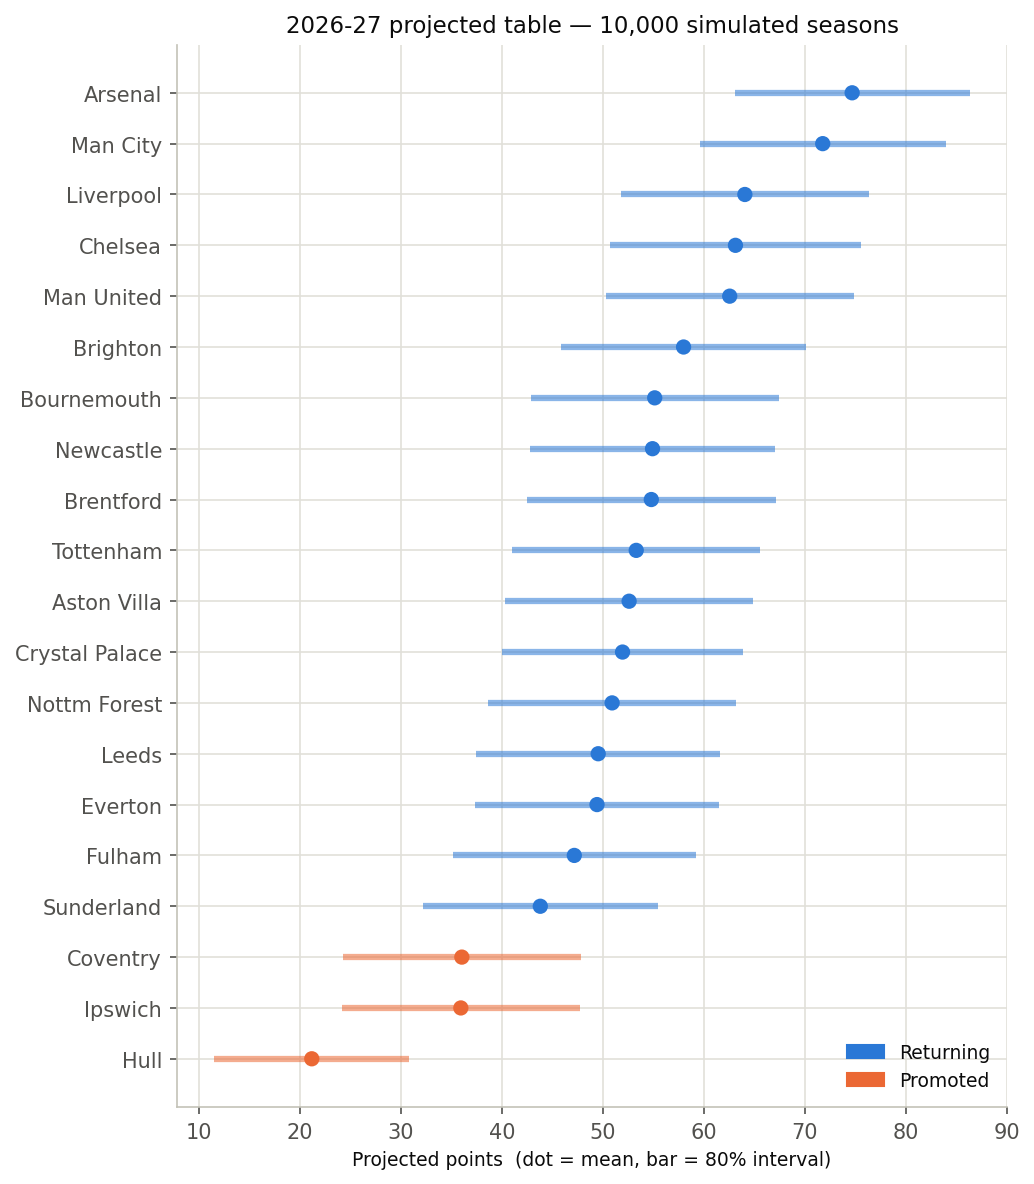

In [5]:
C_XG, C_GOALS = '#2a78d6', '#eb6834'   # same validated categorical pair as champ_analysis.ipynb / priors notebook
C_GRID, C_AXIS, C_INK, C_INK2 = '#e1e0d9', '#c3c2b7', '#0b0b0b', '#52514e'
plt.rcParams.update({
    'figure.dpi': 150, 'font.family': 'sans-serif',
    'axes.edgecolor': C_AXIS, 'axes.labelcolor': C_INK, 'text.color': C_INK,
    'xtick.color': C_INK2, 'ytick.color': C_INK2,
    'axes.grid': True, 'grid.color': C_GRID, 'grid.linewidth': 0.8, 'axes.axisbelow': True,
})

plot_df = avg_table.sort_values('avg_points')
colors = [C_GOALS if p else C_XG for p in plot_df['promoted']]

fig, ax = plt.subplots(figsize=(7, 8))
ax.hlines(plot_df['team'], plot_df['pts_low'], plot_df['pts_high'], color=colors, linewidth=3, alpha=0.55)
ax.scatter(plot_df['avg_points'], plot_df['team'], color=colors, s=40, zorder=3)
ax.set_xlabel('Projected points  (dot = mean, bar = 80% interval)', fontsize=9)
ax.set_title('2026-27 projected table — 10,000 simulated seasons', fontsize=11, color=C_INK)
ax.spines[['top', 'right']].set_visible(False)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=C_XG, label='Returning'), Patch(color=C_GOALS, label='Promoted')],
          loc='lower right', frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / '2026_27_projected_table.png', dpi=150, bbox_inches='tight')
plt.show()

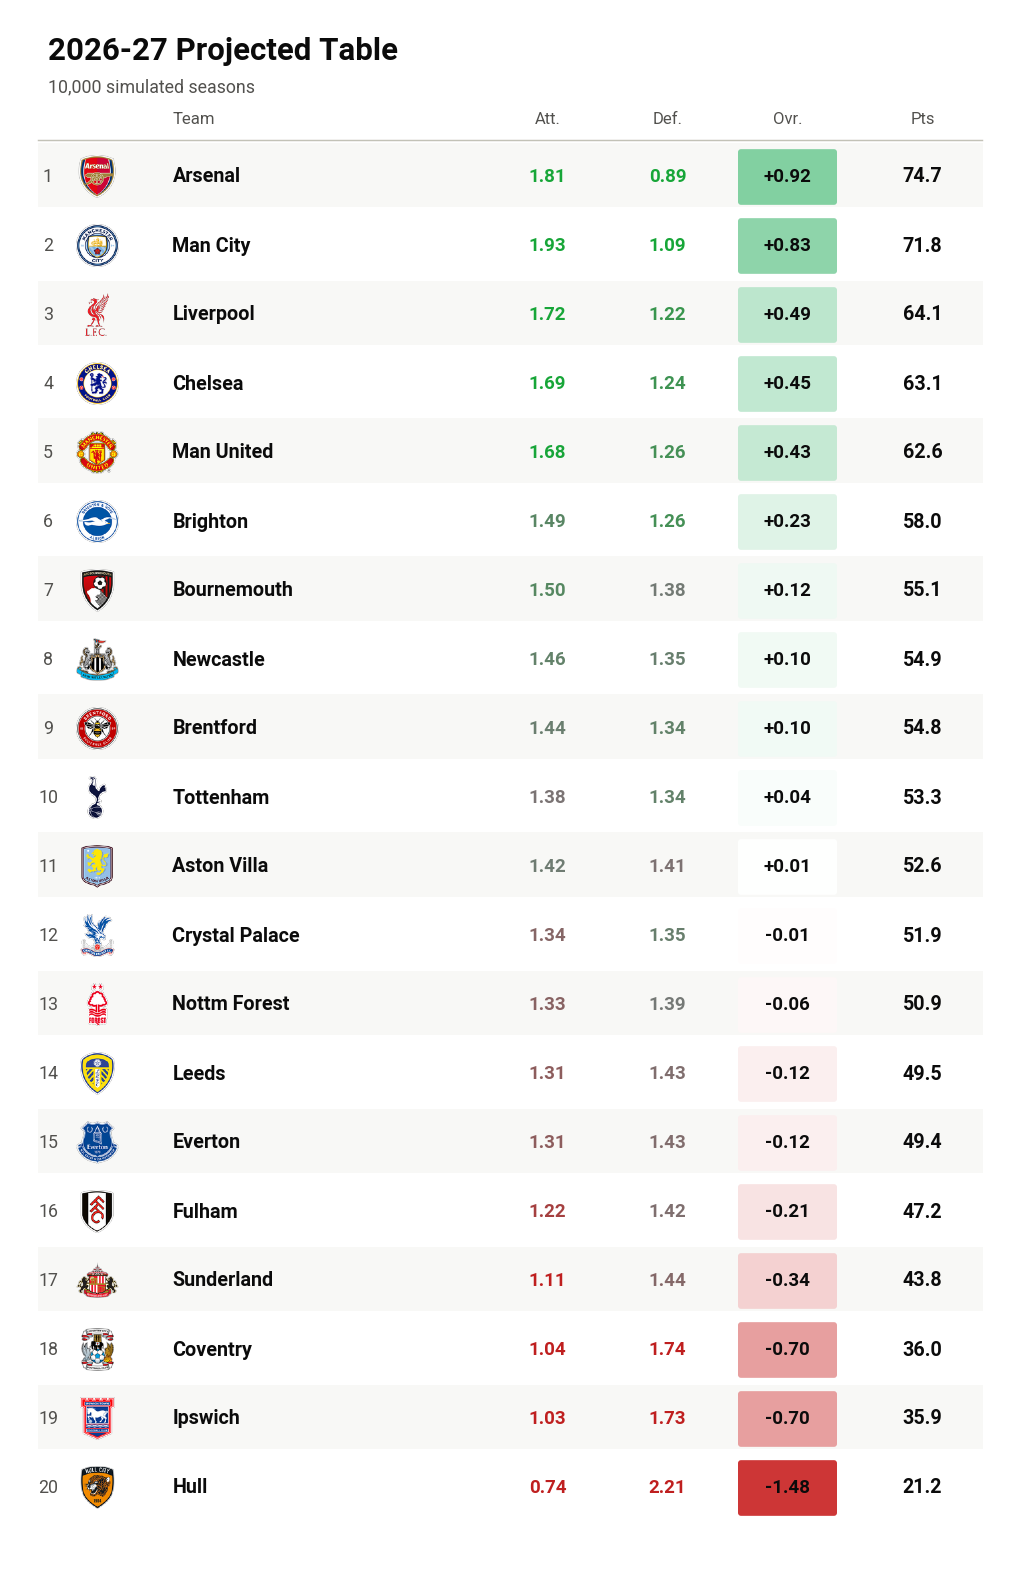

In [6]:
# Simplified leaderboard: logo, Att./Def./Ovr. per-game ratings, projected points.
# Same badge-rendering + colour-coding approach as viz/pl_combined_table.py's
# 538-style table (reuses its _fetch_badge/_xgd_color/_stat_font_color
# helpers) but stripped down to just these columns -- no title/top5/rel%
# columns, no position-distribution bars. Att./Def. get subtle colour-shifted
# text (green-ish toward better, red-ish toward worse, relative to the
# league's own spread this season); Ovr. gets the same soft tinted-cell
# treatment the original chart uses for its xGD column.
import matplotlib.patches as mpatches
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

REPO_ROOT = str(NOTEBOOK_DIR.parents[4])
if os.path.join(REPO_ROOT, 'viz') not in sys.path:
    sys.path.insert(0, os.path.join(REPO_ROOT, 'viz'))
from logos import TEAM_LOGOS as team_logos
from pl_combined_table import _fetch_badge, _xgd_color, _stat_font_color

GAMES = 38
board = avg_table.copy()
board['g_pg']  = board['avg_goals_for'] / GAMES
board['gc_pg'] = board['avg_goals_against'] / GAMES
board['gd_pg'] = board['avg_goal_difference'] / GAMES
board = board.sort_values(
    ['avg_points', 'avg_goal_difference', 'avg_goals_for'], ascending=False
).reset_index(drop=True)

avg_g_pg,  spread_g_pg  = board['g_pg'].mean(),  max(board['g_pg'].std(), 0.05)
avg_gc_pg, spread_gc_pg = board['gc_pg'].mean(), max(board['gc_pg'].std(), 0.05)

badge_cache = {}
for url in set(team_logos.get(t) for t in board['team']):
    if url:
        badge_cache[url] = _fetch_badge(url)
missing_logos = [t for t in board['team'] if team_logos.get(t) is None]
if missing_logos:
    print(f'No logo URL for: {missing_logos}')

ROW_H, PAD_TOP, PAD_BOT, FIG_W = 0.46, 0.85, 0.25, 6.6
FIG_H = len(board) * ROW_H + PAD_TOP + PAD_BOT
X_RANK, X_BADGE, X_NAME = 0.22, 0.55, 1.05
X_G, X_GC, X_GD, X_PTS = 3.55, 4.35, 5.15, 6.05

fig = plt.figure(figsize=(FIG_W, FIG_H))
fig.patch.set_facecolor('white')
ax = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(0, FIG_W); ax.set_ylim(0, FIG_H); ax.axis('off')

ax.text(X_RANK, FIG_H - 0.15, '2026-27 Projected Table', fontsize=15, fontweight='bold', color=C_INK, va='top', ha='left')
ax.text(X_RANK, FIG_H - 0.42, f'{N_SIMS:,} simulated seasons', fontsize=8.5, color=C_INK2, va='top', ha='left')

hdr_y = FIG_H - PAD_TOP + 0.15
for x, lbl in [(X_NAME, 'Team'), (X_G, 'Att.'), (X_GC, 'Def.'), (X_GD, 'Ovr.'), (X_PTS, 'Pts')]:
    ax.text(x, hdr_y, lbl, fontsize=8, color=C_INK2, va='center', ha='left' if x == X_NAME else 'center')
ax.plot([0.15, FIG_W - 0.15], [hdr_y - 0.13, hdr_y - 0.13], color=C_AXIS, lw=0.7)

for i, row in board.iterrows():
    row_top = FIG_H - PAD_TOP - i * ROW_H
    row_mid = row_top - ROW_H / 2
    ax.add_patch(mpatches.Rectangle(
        (0.15, row_top - ROW_H + 0.03), FIG_W - 0.30, ROW_H - 0.03,
        facecolor='#f8f8f6' if i % 2 == 0 else 'white', edgecolor='none', zorder=0))
    ax.text(X_RANK, row_mid, str(i + 1), fontsize=8.5, va='center', ha='center', color=C_INK2)

    url = team_logos.get(row['team'])
    if url and badge_cache.get(url) is not None:
        im = OffsetImage(badge_cache[url], zoom=96 / 300)
        ax.add_artist(AnnotationBbox(im, (X_BADGE, row_mid), frameon=False, zorder=2))

    ax.text(X_NAME, row_mid, row['team'], fontsize=9.5, va='center', ha='left', color=C_INK, fontweight='bold')
    ax.text(X_G,  row_mid, f"{row['g_pg']:.2f}", fontsize=9, va='center', ha='center', fontweight='bold',
            color=_stat_font_color(row['g_pg'], avg_g_pg, spread_g_pg, 'high'))
    ax.text(X_GC, row_mid, f"{row['gc_pg']:.2f}", fontsize=9, va='center', ha='center', fontweight='bold',
            color=_stat_font_color(row['gc_pg'], avg_gc_pg, spread_gc_pg, 'low'))

    cw, ch = 0.62, ROW_H * 0.72
    ax.add_patch(mpatches.FancyBboxPatch(
        (X_GD - cw / 2, row_mid - ch / 2), cw, ch,
        boxstyle='round,pad=0.02', facecolor=_xgd_color(row['gd_pg']),
        edgecolor='none', zorder=1))
    ax.text(X_GD, row_mid, f"{row['gd_pg']:+.2f}", fontsize=9, va='center', ha='center', color=C_INK, fontweight='bold', zorder=2)

    ax.text(X_PTS, row_mid, f"{row['avg_points']:.1f}", fontsize=9.5, va='center', ha='center', color=C_INK, fontweight='bold')

plt.savefig(OUT_DIR / '2026_27_leaderboard.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()


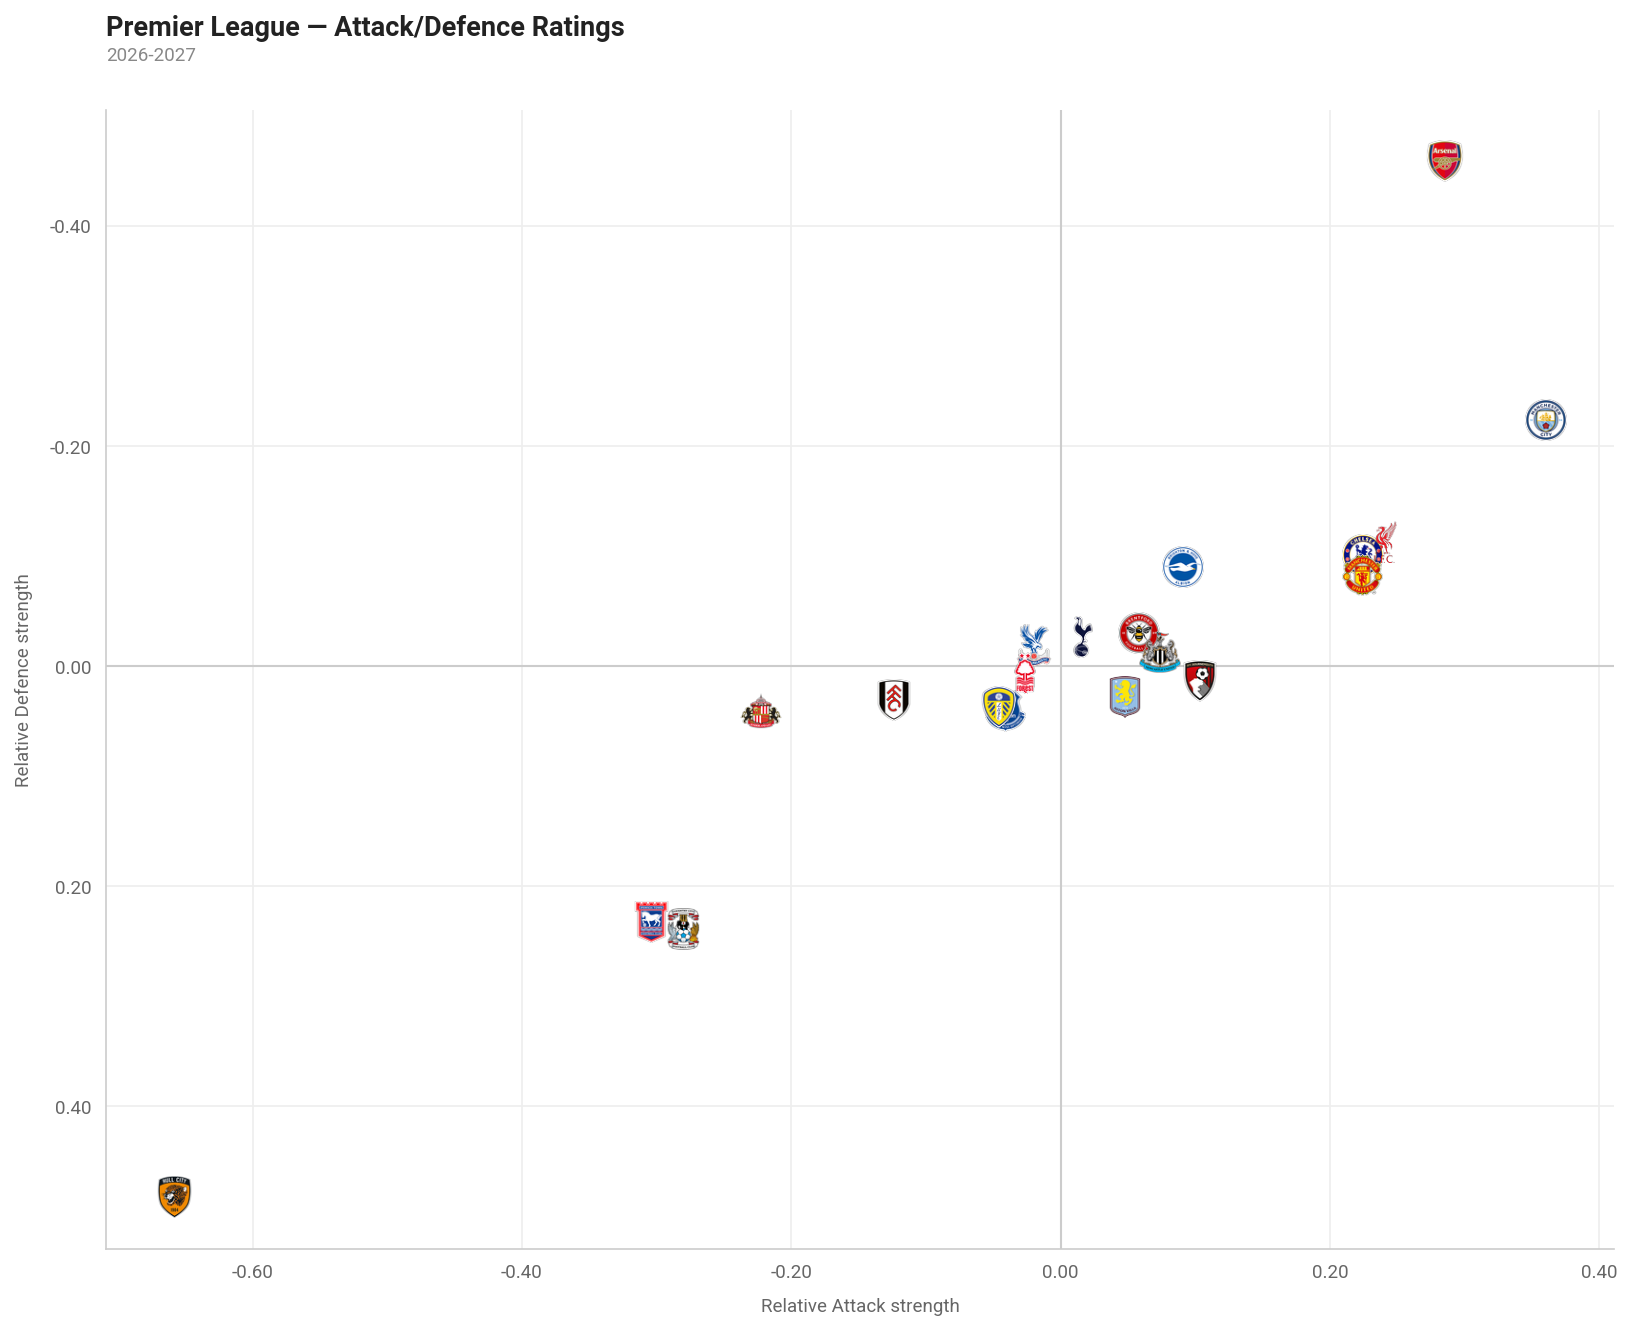

In [7]:
# Attack/Defence scatter, same as outputs.ipynb's `render_scatter` (copied
# directly, unmodified). outputs.ipynb builds `ratings` from a real posterior
# fit on this season's actual matches -- there is no such posterior for
# 2026-27 yet, so the equivalent belief state here is the prior mean itself
# (mu_att/mu_def from manual_priors_2026_27.py, already computed in cell 1 --
# this *is* the model's current belief about each team's att/def strength).
from pl_scatter import render_scatter

ratings_scatter = pd.DataFrame({'team': teams, 'att_mean': mu_att, 'def_mean': mu_def})

fig = render_scatter(ratings_scatter, season='2026-2027', league='Premier League',
    save_path=os.path.join(str(NOTEBOOK_DIR), 'outputs', 'rating_scatter.png'))
plt.show()
